# 01 — Exploração do corpus de receitas

Antes de treinar qualquer coisa, é preciso saber o que há no corpus: quantas
receitas, de que tipo, com que tamanho. Essas respostas determinam escolhas
concretas do treino — o `max_length`, o número de épocas, e o que esperar de
qualidade no fim.

**Fonte:** [Livro de receitas](https://pt.wikibooks.org/wiki/Livro_de_receitas)
do Wikilivros, licença CC-BY-SA 3.0.

**Pré-requisito:** rodar a coleta e o preparo antes deste notebook.

```bash
uv run python -m tech_challenge_fase_04.dados.coleta
uv run python -m tech_challenge_fase_04.dados.preparo
uv run python -m tech_challenge_fase_04.dados.corpus
```

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from tech_challenge_fase_04.avaliacao.visual import (
    AQUA, AZUL, LARANJA, TINTA_SECUNDARIA, aplicar_estilo, rotular_barras,
)

aplicar_estilo()

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURAS = RAIZ / "reports" / "figures"
FIGURAS.mkdir(parents=True, exist_ok=True)

receitas = [json.loads(l) for l in (RAIZ / "data/processed/receitas.jsonl").open(encoding="utf-8")]
df = pd.DataFrame(receitas)
df["n_ingredientes"] = df["ingredientes"].map(len)
df["n_passos"] = df["preparo"].map(len)
df["n_caracteres"] = df.apply(
    lambda r: len(" ".join(r["ingredientes"]) + " ".join(r["preparo"])), axis=1
)

print(f"{len(df)} receitas extraídas de {df['fonte_titulo'].nunique()} páginas do Wikilivros")
df[["titulo", "categoria", "n_ingredientes", "n_passos"]].head()

Matplotlib is building the font cache; this may take a moment.


2506 receitas extraídas de 1827 páginas do Wikilivros


,titulo,categoria,n_ingredientes,n_passos
0,Aluá,Geral,5,4
1,Aluá,Geral,4,4
2,Aluá,Geral,5,2
3,Antepasto de berinjelas à Cristina Ruschel,Canapés e Antepastos,9,3
4,Amarula,Bebidas com álcool,5,2


## Quantas receitas por página?

O Wikilivros usa o padrão `Nome do prato - 1`, `- 2` para variações da mesma
preparação. Cada variação é um texto distinto e entra como exemplo próprio —
por isso o número de receitas supera o de páginas.

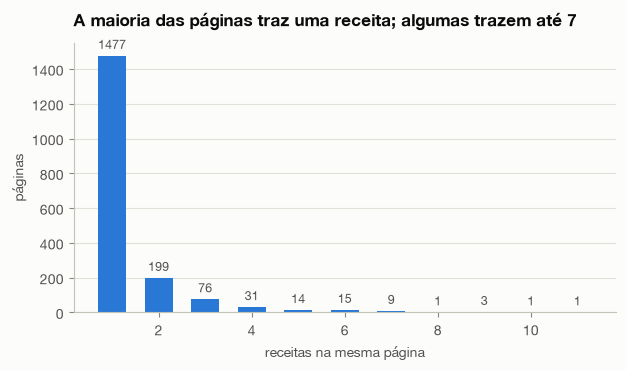

média de 1.37 receitas por página


In [2]:
por_pagina = df.groupby("fonte_titulo").size().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(por_pagina.index, por_pagina.values, color=AZUL, width=0.6)
rotular_barras(ax)
ax.set_title("A maioria das páginas traz uma receita; algumas trazem até 7")
ax.set_xlabel("receitas na mesma página")
ax.set_ylabel("páginas")
plt.show()

print(f"média de {len(df) / df['fonte_titulo'].nunique():.2f} receitas por página")

## Tamanho das receitas

Define o `max_length` do treino. Truncar corta o fim da receita — justamente o
modo de preparo, que é o que o modelo mais precisa aprender a escrever.

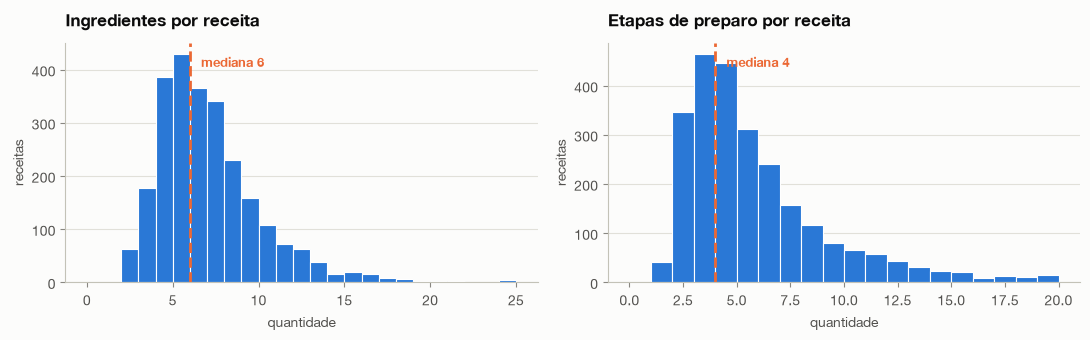

,n_ingredientes,n_passos,n_caracteres
count,2506.0,2506.0,2506.0
mean,6.6,5.5,575.9
std,3.0,3.6,360.3
min,2.0,1.0,108.0
25%,5.0,3.0,325.0
50%,6.0,4.0,482.5
75%,8.0,7.0,723.2
max,30.0,37.0,3255.0


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

ax1.hist(df["n_ingredientes"], bins=range(0, 26), color=AZUL, edgecolor="white", linewidth=0.8)
ax1.set_title("Ingredientes por receita")
ax1.set_xlabel("quantidade")
ax1.set_ylabel("receitas")
ax1.axvline(df["n_ingredientes"].median(), color=LARANJA, linewidth=2, linestyle="--")
ax1.annotate(
    f"mediana {df['n_ingredientes'].median():.0f}",
    (df["n_ingredientes"].median(), ax1.get_ylim()[1] * 0.9),
    xytext=(8, 0), textcoords="offset points", color=LARANJA, fontsize=9, fontweight="bold",
)

ax2.hist(df["n_passos"], bins=range(0, 21), color=AZUL, edgecolor="white", linewidth=0.8)
ax2.set_title("Etapas de preparo por receita")
ax2.set_xlabel("quantidade")
ax2.set_ylabel("receitas")
ax2.axvline(df["n_passos"].median(), color=LARANJA, linewidth=2, linestyle="--")
ax2.annotate(
    f"mediana {df['n_passos'].median():.0f}",
    (df["n_passos"].median(), ax2.get_ylim()[1] * 0.9),
    xytext=(8, 0), textcoords="offset points", color=LARANJA, fontsize=9, fontweight="bold",
)

plt.tight_layout()
plt.savefig(FIGURAS / "01_tamanho_receitas.png")
plt.show()

df[["n_ingredientes", "n_passos", "n_caracteres"]].describe().round(1)

## Distribuição em tokens

O que importa para o modelo não é o número de caracteres, e sim de *tokens* do
tokenizador. É esse número que decide o `max_length` e o custo de cada passo.

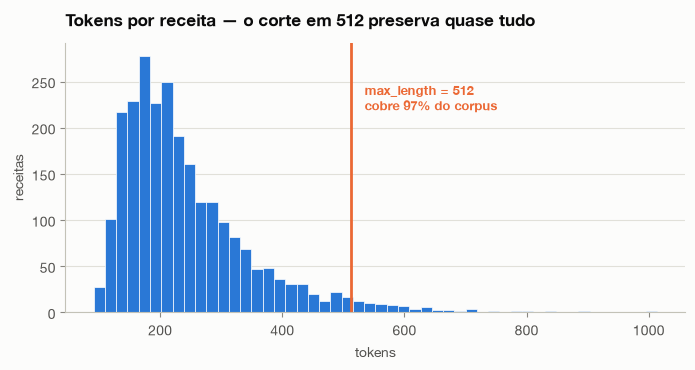

total de tokens no corpus: 607,688
  max_length=256: cobre 66.7%
  max_length=384: cobre 90.1%
  max_length=512: cobre 96.8%
  max_length=768: cobre 99.8%


In [4]:
from transformers import AutoTokenizer

from tech_challenge_fase_04.dados.corpus import formatar

tokenizador = AutoTokenizer.from_pretrained("pierreguillou/gpt2-small-portuguese")
tamanhos = pd.Series(
    [len(tokenizador(formatar(r, "por-titulo")).input_ids) for r in receitas]
)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(tamanhos, bins=50, color=AZUL, edgecolor="white", linewidth=0.5)
for limite, cor in [(512, LARANJA)]:
    cobertura = (tamanhos <= limite).mean()
    ax.axvline(limite, color=cor, linewidth=2)
    ax.annotate(
        f"max_length = {limite}\ncobre {cobertura:.0%} do corpus",
        (limite, ax.get_ylim()[1] * 0.75),
        xytext=(10, 0), textcoords="offset points",
        color=cor, fontsize=9, fontweight="bold",
    )
ax.set_title("Tokens por receita — o corte em 512 preserva quase tudo")
ax.set_xlabel("tokens")
ax.set_ylabel("receitas")
plt.savefig(FIGURAS / "01_tokens_por_receita.png")
plt.show()

print(f"total de tokens no corpus: {tamanhos.sum():,}")
for limite in (256, 384, 512, 768):
    print(f"  max_length={limite}: cobre {(tamanhos <= limite).mean():.1%}")

## Categorias

As categorias vêm das etiquetas do próprio Wikilivros. São elas que alimentam o
seletor do playground e permitem condicionar a geração.

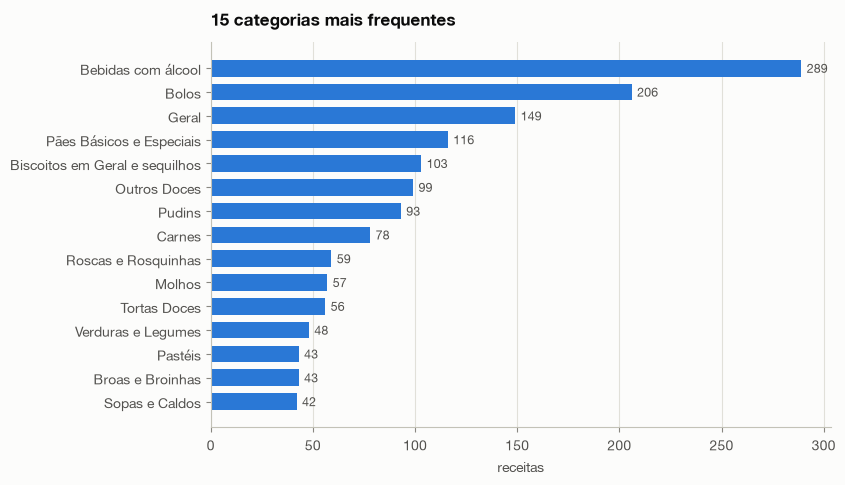

99 categorias distintas
receitas sem categoria útil ('Geral'): 149


In [5]:
top = df["categoria"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=AZUL, height=0.7)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
for barra, valor in zip(ax.patches, top.values):
    ax.annotate(
        str(valor), (valor, barra.get_y() + barra.get_height() / 2),
        xytext=(4, 0), textcoords="offset points",
        va="center", fontsize=9, color=TINTA_SECUNDARIA,
    )
ax.set_title("15 categorias mais frequentes")
ax.set_xlabel("receitas")
plt.savefig(FIGURAS / "01_categorias.png")
plt.show()

print(f"{df['categoria'].nunique()} categorias distintas")
print(f"receitas sem categoria útil ('Geral'): {(df['categoria'] == 'Geral').sum()}")

## Ingredientes mais comuns

Uma leitura de sanidade: o vocabulário culinário que o modelo vai absorver.

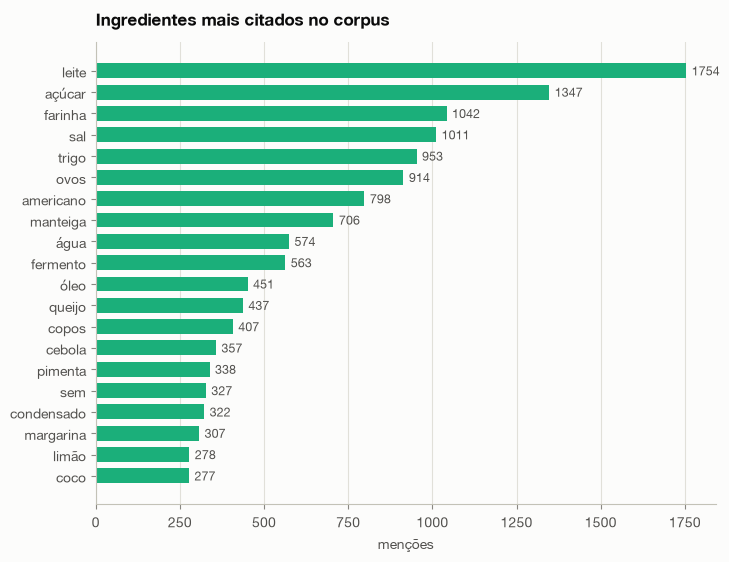

In [6]:
import re

PARADAS = {
    "de", "a", "o", "e", "com", "em", "para", "da", "do", "das", "dos", "ou",
    "sopa", "chá", "xícara", "xícaras", "colher", "colheres", "copo", "gosto",
    "picado", "picada", "ralado", "ralada", "gramas", "kg", "ml", "litro",
    "litros", "lata", "pitada", "un", "cerca", "quanto", "baste", "grande",
    "médio", "pequeno", "pequena", "grandes", "bem", "opcional",
}

palavras = Counter()
for lista in df["ingredientes"]:
    for item in lista:
        for palavra in re.findall(r"[a-zà-ú]{3,}", item.lower()):
            if palavra not in PARADAS:
                palavras[palavra] += 1

top_ing = pd.Series(dict(palavras.most_common(20))).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_ing.index, top_ing.values, color=AQUA, height=0.7)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
for barra, valor in zip(ax.patches, top_ing.values):
    ax.annotate(
        str(valor), (valor, barra.get_y() + barra.get_height() / 2),
        xytext=(4, 0), textcoords="offset points",
        va="center", fontsize=9, color=TINTA_SECUNDARIA,
    )
ax.set_title("Ingredientes mais citados no corpus")
ax.set_xlabel("menções")
plt.savefig(FIGURAS / "01_ingredientes.png")
plt.show()

## Como fica um exemplo de treino

O formato final que o modelo vê. Os delimitadores `<|receita|>` e `<|fim|>`
ensinam onde começa e — o mais importante para o playground — onde termina.

In [7]:
from tech_challenge_fase_04.dados.corpus import formatar

exemplo = next(r for r in receitas if 8 <= len(r["ingredientes"]) <= 10)
print(formatar(exemplo, "por-titulo"))
print("\n" + "=" * 70 + "\n")
print(formatar(exemplo, "por-ingredientes"))

<|receita|>
MODO: por-titulo
CATEGORIA: Canapés e Antepastos
TÍTULO: Antepasto de berinjelas à Cristina Ruschel
INGREDIENTES:
- 4 berinjelas médias
- 2 pimentões vermelhos ou amarelos
- 1 cabeça de alho (no mínimo)
- Entre 50 e 100 gramas de uvas-passas brancas
- 1 vidro de azeitona em conserva fatiada
- Azeite de oliva extra virgem
- Aceto balsâmico
- Orégano
- Glutamato monossódico
PREPARO:
1. Descasque as berinjelas e corte-as em fatias finas na forma de meia lua. Corte os pimentões em tirinhas. Fatie o alho, bem fininho. Escolha uma panela com mais de 30 centímetros de diâmetro. Cubra o fundo com o azeite, em uma porção bem generosa. Refogue o alho, tomando muito cuidado para não queimar. Acrescente as berinjelas, mexa bem e deixe cozinhar por alguns minutos
2. Se suas fatias de pimentão tiverem mais de quatro milímetros, coloque-as na panela assim que a berinjela começar a escurecer. Caso sejam mais finas, espere elas cozinharem mais, ou o pimentão desaparecerá, causando prejuízos

## Conclusões que orientam o treino

| Observação | Decisão |
|---|---|
| 2.506 receitas, ~650 mil tokens | Corpus pequeno: 3 épocas, *learning rate* baixo, atenção a decorar |
| 97% cabem em 512 tokens | `max_length=512` |
| Variações na mesma página são quase-duplicatas | Split treino/validação **por página**, não por receita |
| Estrutura muito regular | O modelo deve aprender o formato rápido; a métrica interessante é originalidade, não perplexidade |